<a href="https://colab.research.google.com/github/yunayana/Sztuczna_Inteligancja_STAC_2026/blob/main/Lab1_Model_liniowy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [2]:
observations=1000
xs = np.random.uniform(low=-10, high=10, size=(observations, 1))
zs = np.random.uniform(low=-10, high=10, size=(observations, 1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)

(1000, 2)


In [3]:
noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 13 * xs + 7 * zs - 12 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(1000, 1)


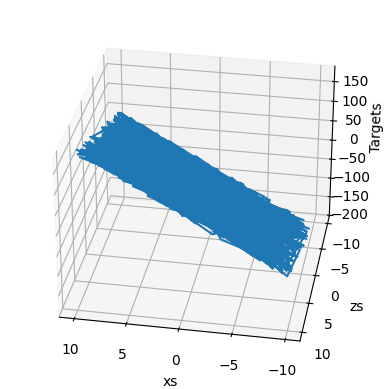

In [5]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, zs, targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [6]:

init_range= 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights, biases)

[[-0.08178107]
 [ 0.01283317]] [-0.03699114]


In [7]:
targets = targets.reshape(observations, 1)
eta = 0.02
for i in range (1000):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2)/2/observations
  print(loss)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

3644.5994011296443
519.0337495396052
122.62356444534655
70.35455824668361
61.5906455346102
58.40404235170173
56.0040650378023
53.78249456666071
51.659371256566374
49.621588193881195
47.66460444067464
45.785075774462
43.979918853699736
42.24618859039242
40.58105848236227
38.98181412607482
37.44584855416933
35.97065795573316
34.55383759098622
33.1930778707824
31.886160591638465
30.630955319785407
29.425415918301763
28.26757721166221
27.15555178226275
26.087526893701177
25.06176153579653
24.076583586531388
23.130387086289957
22.22162961994903
21.348829802554167
20.510564864482443
19.705468332155256
18.932227800520618
18.189582793673623
17.47632271012775
16.791284849387548
16.133352516605683
15.501453202234883
14.89455683370716
14.311674096290501
13.751854820385924
13.214186432635554
12.697792468317385
12.201831142601458
11.725493978338335
11.268004488143294
10.828616908627671
10.406614984713979
10.001310802053249
9.61204366564113
9.238179022804893
8.879107428805513
8.534243553368851
8.203

In [8]:
print(weights, biases)

[[12.99862104]
 [ 7.00789583]] [-12.03599643]


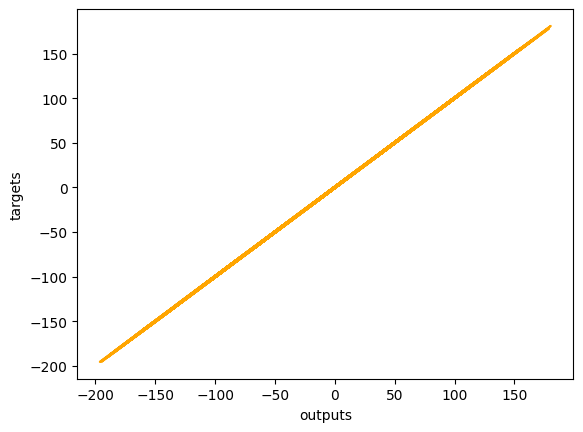

In [10]:
plt.plot(outputs.flatten(), targets.flatten(), color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()